In [1]:
# change kernel to widget
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
from dask.diagnostics import ProgressBar
#%matplotlib widget

In [ ]:
# build/write file
ds_list = [
    xr.open_dataset(f'ncmu{i}_hourly_pertransect.nc', chunks={'time': 2000})
    for i in range(4)
]

mu_total = ds_list[0]['mu'] + ds_list[1]['mu'] + ds_list[2]['mu'] + ds_list[3]['mu']

out = mu_total.to_dataset(name='mu')

encoding = {'mu': {'zlib': True, 'complevel': 4, 'dtype': 'float32'}}

with ProgressBar():
    out.to_netcdf('ncmu_total_hourly_pertransect.nc', encoding=encoding)

[####                                    ] | 12% Completed | 150.19 s

In [7]:
# OR load file
mu_total = xr.open_dataarray('ncmu_total_hourly_pertransect.nc', chunks='auto')

In [6]:
# perpare landsat mosaic
IMG_DIR = Path("imagery")

red_files = [IMG_DIR / f for f in [
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B4.TIF',
    'LC08_L2SP_014036_20170409_20200904_02_T1_SR_B4.TIF',
    'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B4.TIF',
    'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B4.TIF',
]]

green_files = [IMG_DIR / f for f in [
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B3.TIF',
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B3.TIF',
    'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B3.TIF',
    'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B3.TIF',
]]

blue_files = [IMG_DIR / f for f in [
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B2.TIF',
    'LC08_L2SP_014036_20170409_20200904_02_T1_SR_B2.TIF',
    'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B2.TIF',
    'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B2.TIF',
]]

def mosaic_band(file_list):
    """Opens a list of TIFs and merges them into one array."""
    elements = [rxr.open_rasterio(f, masked=True).squeeze() for f in file_list]
    return merge_arrays(elements)

print("Mosaicking bands... ")
merged_red = mosaic_band(red_files)
merged_green = mosaic_band(green_files)
merged_blue = mosaic_band(blue_files)

rgb = xr.concat([merged_red, merged_green, merged_blue], dim='band')
rgb['band'] = [1, 2, 3]

rgb_scaled = (rgb / 20000).clip(0, 1)
print('Done! :)')

Mosaicking bands... 
Done! :)


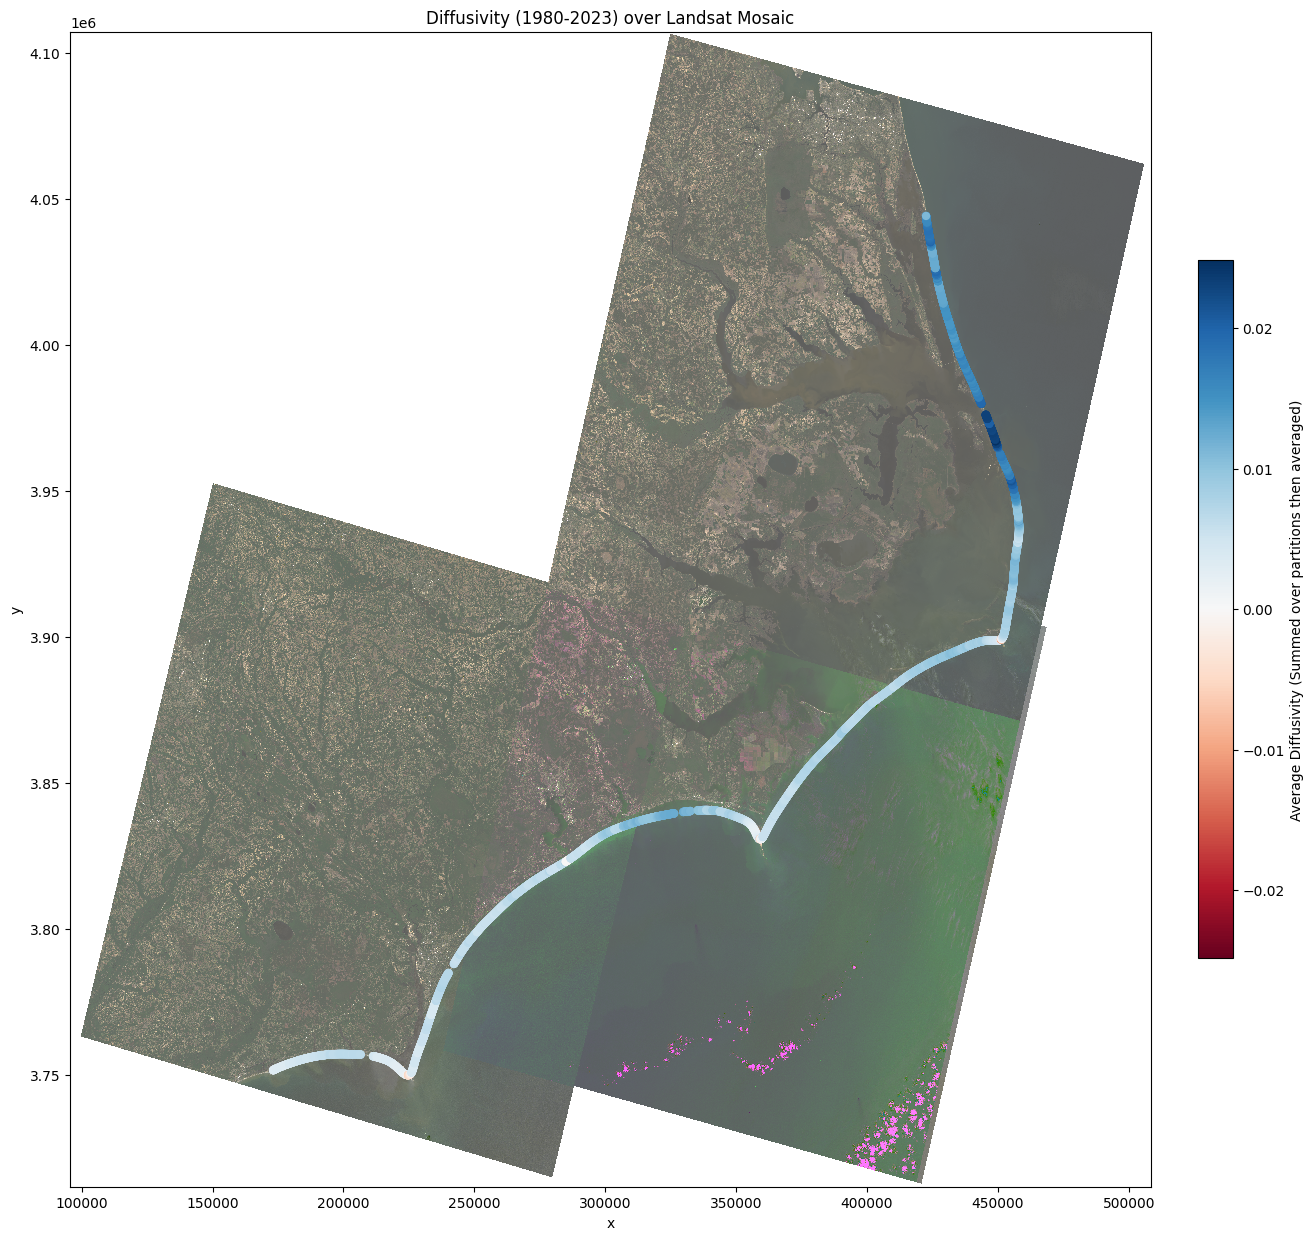

In [8]:
sum_transport = mu_total.mean(dim='time').compute()
mean_lon = mu_total['lon']
mean_lat = mu_total['lat']

gdf = gpd.GeoDataFrame(
    {'mu': sum_transport.values},
    geometry=gpd.points_from_xy(mean_lon, mean_lat),
    crs="EPSG:4326"
)
gdf = gdf.to_crs(rgb.rio.crs)

fig, ax = plt.subplots(figsize=(15, 15))

rgb_scaled.plot.imshow(rgb='band', ax=ax)

limit = max(abs(np.nanmax(sum_transport)), abs(np.nanmin(sum_transport)))
scatter = ax.scatter(
    gdf.geometry.x, 
    gdf.geometry.y, 
    c=gdf['mu'],
    vmin=-limit, vmax=limit,
    cmap='RdBu', 
    s=25
)

plt.colorbar(scatter, label='Average Diffusivity (Summed over partitions then averaged)', fraction=0.03, pad=0.04)
plt.title(f"Diffusivity (1980-2023) over Landsat Mosaic")
# ax.set_axis_off() # hides UTM coordinates
plt.show()